In [1]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import os

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Carregando o dataset de terremotos e tsunamis
df = pd.read_csv('earthquake_data_tsunami.csv')

# Visualizando as primeiras linhas
df.head()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


In [3]:
# Verificando o tamanho do dataset
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

# Verificando os tipos de dados e valores nulos
df.info()

Linhas: 782
Colunas: 13
<class 'pandas.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.6 KB


Distribuição da variável alvo:
tsunami
0    478
1    304
Name: count, dtype: int64


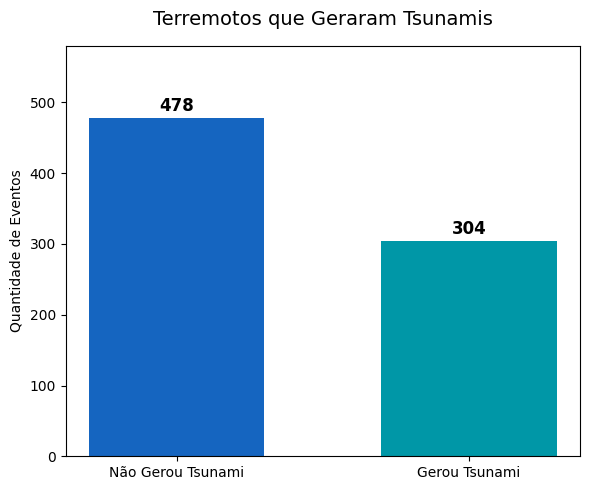

In [4]:
# Distribuição de eventos com e sem tsunami
print("Distribuição da variável alvo:")
print(df['tsunami'].value_counts())

plt.figure(figsize=(6,5))
cores = ['#1565C0', '#0097A7']
valores = df['tsunami'].value_counts().sort_index()
barras = plt.bar(['Não Gerou Tsunami', 'Gerou Tsunami'], valores, color=cores, width=0.6)
plt.title('Terremotos que Geraram Tsunamis', fontsize=14, pad=15)
plt.ylabel('Quantidade de Eventos')
plt.ylim(0, 580)
for barra in barras:
    plt.text(barra.get_x() + barra.get_width()/2,
             barra.get_height() + 10,
             str(int(barra.get_height())),
             ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\enzoy\AppData\Local\Temp\ipykernel_22728\49778794.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tsunami', y='magnitude', data=df,


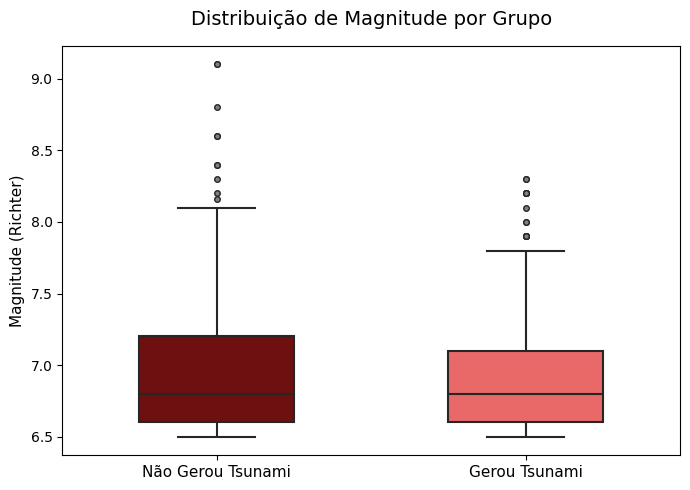

In [5]:
# Distribuição de magnitude por grupo
# Boxplot mostra a variação completa: mediana, 50% dos dados e outliers
plt.figure(figsize=(7,5))
sns.boxplot(x='tsunami', y='magnitude', data=df,
            palette=['#7F0000', '#FF5252'],
            width=0.5, linewidth=1.5,
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=4))
plt.title('Distribuição de Magnitude por Grupo', fontsize=14, pad=15)
plt.xlabel('')
plt.xticks([0, 1], ['Não Gerou Tsunami', 'Gerou Tsunami'], fontsize=11)
plt.ylabel('Magnitude (Richter)', fontsize=11)
plt.tight_layout()
plt.show()

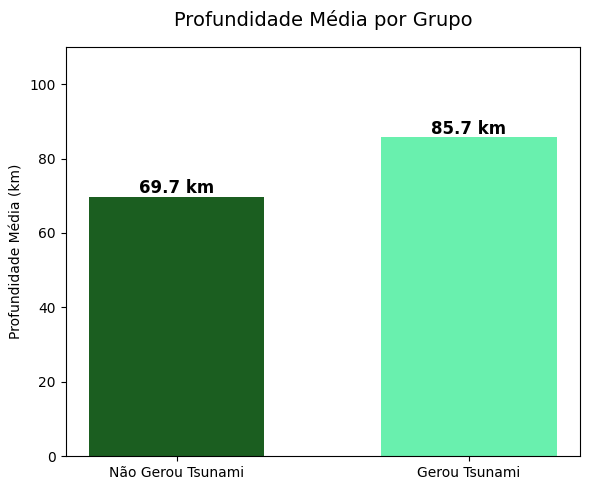

In [6]:
# Profundidade média por grupo
plt.figure(figsize=(6,5))
medias_prof = df.groupby('tsunami')['depth'].mean()
cores = ['#1B5E20', '#69F0AE']
barras = plt.bar(['Não Gerou Tsunami', 'Gerou Tsunami'], medias_prof, color=cores, width=0.6)
plt.title('Profundidade Média por Grupo', fontsize=14, pad=15)
plt.ylabel('Profundidade Média (km)')
plt.ylim(0, 110)
for barra in barras:
    plt.text(barra.get_x() + barra.get_width()/2,
             barra.get_height() + 1,
             f'{barra.get_height():.1f} km',
             ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# Selecionando as features e a variável alvo
# Utilizamos 7 features para capturar melhor os padrões sísmicos
features = ['magnitude', 'depth', 'latitude', 'longitude', 'gap', 'dmin', 'sig']
X = df[features]
y = df['tsunami']

# Dividindo em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Dados de treino: {X_train.shape[0]} linhas")
print(f"Dados de teste: {X_test.shape[0]} linhas")

Dados de treino: 625 linhas
Dados de teste: 157 linhas


In [8]:
# Treinando o modelo Random Forest
# class_weight='balanced' corrige o desbalanceamento entre as classes
modelo = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
modelo.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


In [9]:
# Avaliando o desempenho do modelo
y_pred = modelo.predict(X_test)

acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {acuracia:.2%}")

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Não Tsunami', 'Tsunami']))

Acurácia do modelo: 91.72%

Relatório de Classificação:
              precision    recall  f1-score   support

 Não Tsunami       0.96      0.89      0.93        91
     Tsunami       0.86      0.95      0.91        66

    accuracy                           0.92       157
   macro avg       0.91      0.92      0.92       157
weighted avg       0.92      0.92      0.92       157



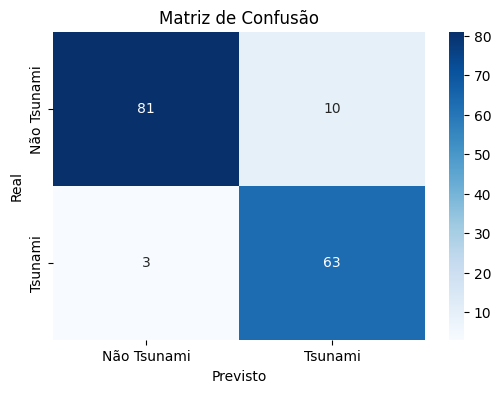

In [10]:
# Matriz de confusão — mostra onde o modelo acertou e onde errou
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Tsunami', 'Tsunami'],
            yticklabels=['Não Tsunami', 'Tsunami'])
plt.title('Matriz de Confusão')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

C:\Users\enzoy\AppData\Local\Temp\ipykernel_22728\1600304897.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias, y=features, palette='Blues_r')


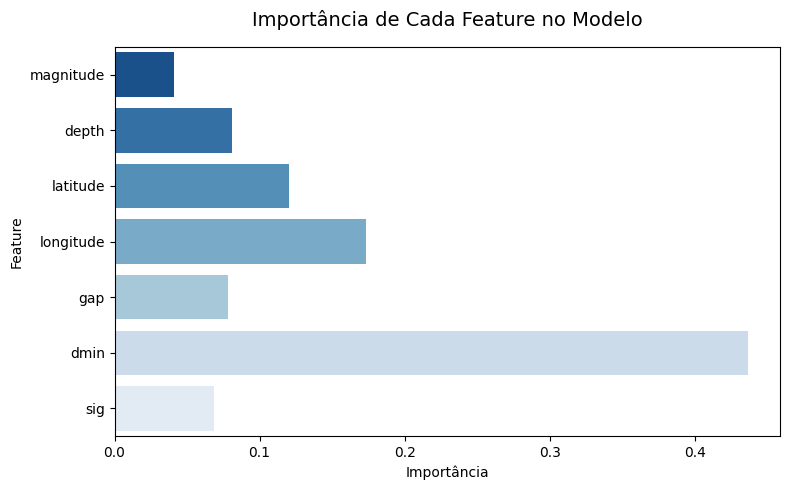

In [11]:
# Importância de cada feature na decisão do modelo
importancias = modelo.feature_importances_

plt.figure(figsize=(8,5))
sns.barplot(x=importancias, y=features, palette='Blues_r')
plt.title('Importância de Cada Feature no Modelo', fontsize=14, pad=15)
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [12]:
# Salvando o modelo treinado para uso na API Flask
joblib.dump(modelo, 'modelo_classificacao.pkl')
print("Modelo salvo com sucesso!")

tamanho = os.path.getsize('modelo_classificacao.pkl')
print(f"Arquivo: modelo_classificacao.pkl")
print(f"Tamanho: {tamanho / 1024:.1f} KB")

Modelo salvo com sucesso!
Arquivo: modelo_classificacao.pkl
Tamanho: 2634.1 KB
